In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/adult.csv")

1


In [3]:
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
print(numeric_columns)

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


2

In [10]:
unique_counts = df.nunique()
for attribute in df.columns:
    data_type = "numeric" if attribute in numeric_columns else "categorical"
    print(f"- {attribute} ({data_type}): {unique_counts[attribute]} ")

- age (numeric): 73 
- workclass (categorical): 9 
- fnlwgt (numeric): 21648 
- education (categorical): 16 
- education-num (numeric): 16 
- marital-status (categorical): 7 
- occupation (categorical): 15 
- relationship (categorical): 6 
- race (categorical): 5 
- sex (categorical): 2 
- capital-gain (numeric): 119 
- capital-loss (numeric): 92 
- hours-per-week (numeric): 94 
- native-country (categorical): 42 
- income (categorical): 2 


3

In [13]:
unique_workclass = df["workclass"].unique()
print(f"Number of unique values: {df['workclass'].nunique()}")
print("\nSorted unique values:")
print(sorted([str(x) for x in unique_workclass]))

Number of unique values: 9

Sorted unique values:
['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']


4

In [16]:
df = df.replace(['?', '-', 'N/A', 'NULL', 'None', ''], pd.NA)

# حالا دوباره بررسی کن
missing_counts = df.isnull().sum()
print(missing_counts)

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


5

In [21]:
country_column = 'native-country'
total_valid = df[country_column].notna().sum()
us_natives = (df[country_column] == "United-States").sum()
percentage = (us_natives/total_valid) * 100
print(f"percentage of us: {percentage:.2f}%")
print(f"total : {total_valid}")
print(f"United States: {us_natives}")

percentage of us: 91.22%
total : 31978
United States: 29170


6

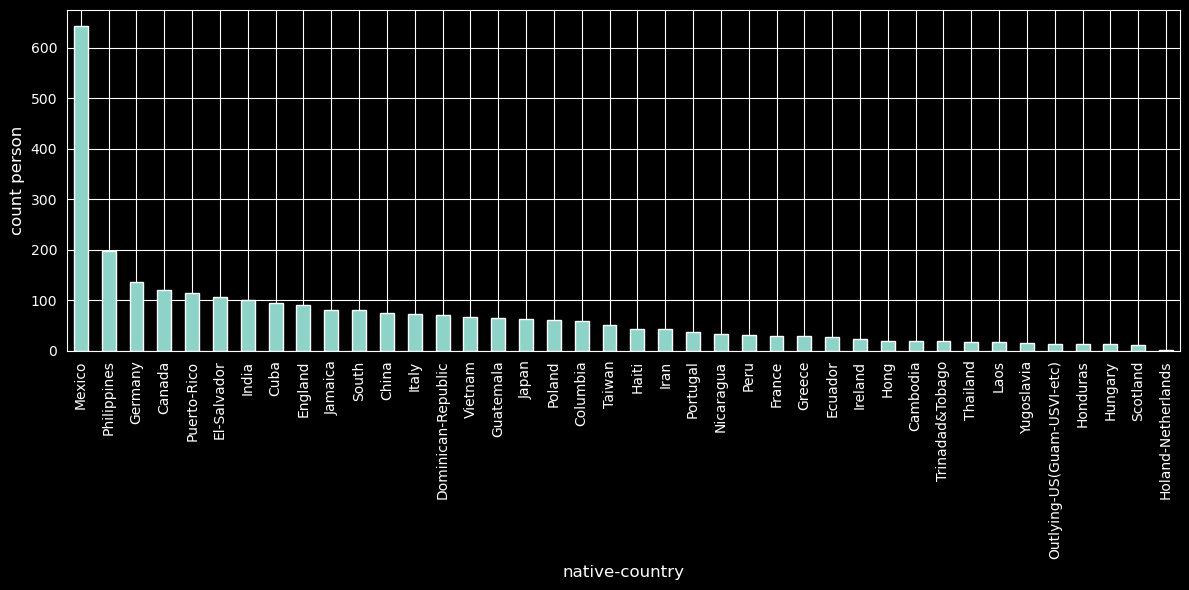

In [28]:
df_clean = df[df[country_column].notna()].copy()
df_filtered = df_clean[df_clean[country_column] != "United-States"]
country_counts = df_filtered[country_column].value_counts()

plt.figure(figsize=(12, 6))
country_counts.plot(kind='bar')
plt.xlabel('native-country', fontsize=12)
plt.ylabel('count person', fontsize=12)
plt.tight_layout()
plt.show()